Assets: ['NIFTYBEES.NS', 'GOLDBEES.NS', 'ITBEES.NS', 'BANKBEES.NS']
Observations: 1237

RISK PARITY RESULTS
Total Return: 72.27 %
Annual Volatility: 10.530000000000001 %
Sharpe: 1.16
Max Drawdown: -16.15 %

EQUAL WEIGHT BENCHMARK
Return: 63.47 %

QUANTSTATS
                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]




Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2021-11-18
End Period           2026-08-20
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    72.27%
CAGR﹪               12.35%

Sharpe               1.16
Prob. Sharpe Ratio   99.36%
Sortino              1.69
Sortino/√2           1.2
Omega                1.22

Max Drawdown         -16.15%
Max DD Date          2026-03-23
Max DD Period Start  2026-01-30
Max DD Period End    2026-08-20
Longest DD Days      220

Gain/Pain Ratio      0.22
Gain/Pain (1M)       1.28

Payoff Ratio         1.01
Profit Factor        1.22
Common Sense Ratio   1.35
CPC Index            0.67
Tail Ratio           1.11
Outlier Win Ratio    3.33
Outlier Loss Ratio   3.62

MTD                  2.29%
3M                   2.82%
6M                   -5.21%
YTD                  -5.39%
1Y  

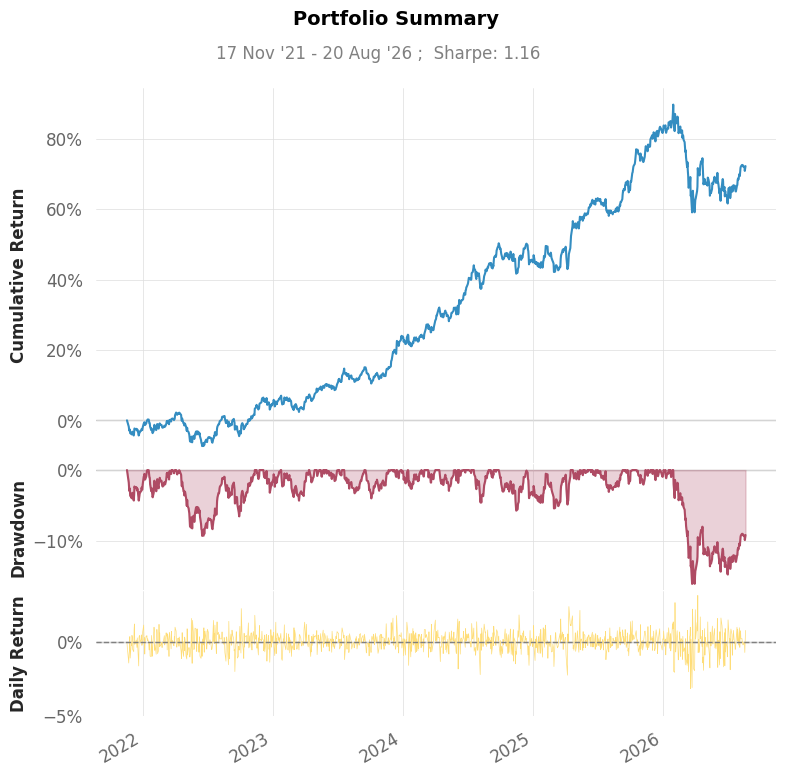

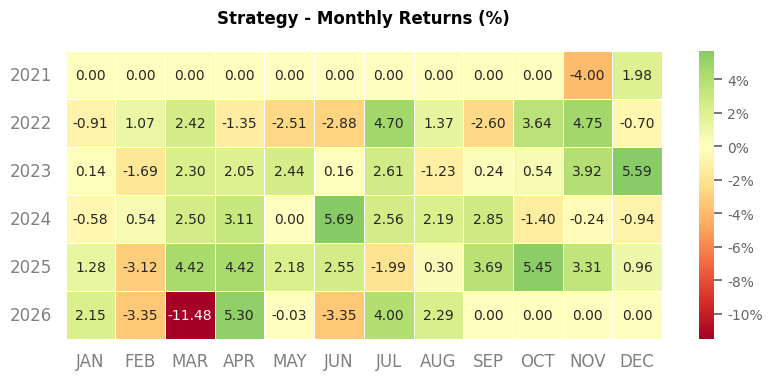


LATEST RISK-PARITY WEIGHTS
              InverseVol  RiskParity
NIFTYBEES.NS      0.3841      0.2994
GOLDBEES.NS       0.1941      0.2264
ITBEES.NS         0.1386      0.1668
BANKBEES.NS       0.2833      0.3075

Risk contribution:
NIFTYBEES.NS    0.2451
GOLDBEES.NS     0.2601
ITBEES.NS       0.2739
BANKBEES.NS     0.2209
dtype: float64


In [9]:
!pip install yfinance quantstats scipy -q

import yfinance as yf
import numpy as np
import pandas as pd
import scipy.optimize as opt
import quantstats as qs

# ============================================================
# 1. DATA
# ============================================================

tickers = [
    "NIFTYBEES.NS",
    "GOLDBEES.NS",
    "ITBEES.NS",
    "BANKBEES.NS"
]

prices = yf.download(
    tickers,
    period="5y",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = prices.pct_change().dropna()

print("Assets:", tickers)
print("Observations:", len(returns))


# ============================================================
# 2. RISK PARITY FUNCTION
# ============================================================

def risk_parity_weights(cov):

    n = len(cov)

    def portfolio_vol(w):
        return np.sqrt(w @ cov @ w)

    def risk_contribution(w):

        vol = portfolio_vol(w)
        marginal = cov @ w
        return w * marginal / vol

    def objective(w):

        rc = risk_contribution(w)

        # Equal risk contribution
        return np.sum(
            (rc - rc.mean()) ** 2
        )

    constraints = {
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    }

    bounds = [(0.01, 0.60)] * n

    x0 = np.ones(n) / n

    result = opt.minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    return result.x


# ============================================================
# 3. MONTHLY PORTFOLIO CONSTRUCTION
# ============================================================

window = 60

portfolio_returns = []
weights_history = []

for i in range(window, len(returns)):

    # Rebalance at beginning of each month
    if (
        i == window
        or returns.index[i].month
        != returns.index[i-1].month
    ):

        lookback = returns.iloc[
            i-window:i
        ]

        # Annualized covariance
        cov = lookback.cov().values * 252

        # ----------------------------------------------------
        # Inverse Volatility
        # ----------------------------------------------------

        vol = lookback.std() * np.sqrt(252)

        inv_vol = 1 / vol

        inv_weights = (
            inv_vol /
            inv_vol.sum()
        )

        # ----------------------------------------------------
        # Correlation-aware Risk Parity
        # ----------------------------------------------------

        rp_weights = risk_parity_weights(cov)

        weights_history.append(
            pd.DataFrame({
                "InverseVol": inv_weights,
                "RiskParity": rp_weights
            }, index=tickers)
        )

        current_weights = rp_weights

    else:

        current_weights = current_weights


    # Portfolio return
    r = returns.iloc[i].values

    portfolio_returns.append(
        np.dot(current_weights, r)
    )


# ============================================================
# 4. STRATEGY RETURNS
# ============================================================

rp_returns = pd.Series(
    portfolio_returns,
    index=returns.index[window:]
)

# Equal-weight benchmark
ew_returns = (
    returns.iloc[window:]
    .mean(axis=1)
)

# ============================================================
# 5. PERFORMANCE
# ============================================================

print("\n" + "="*60)
print("RISK PARITY RESULTS")
print("="*60)

print(
    "Total Return:",
    round(
        (1 + rp_returns).prod() - 1,
        4
    ) * 100,
    "%"
)

print(
    "Annual Volatility:",
    round(
        rp_returns.std() * np.sqrt(252),
        4
    ) * 100,
    "%"
)

print(
    "Sharpe:",
    round(
        rp_returns.mean()
        / rp_returns.std()
        * np.sqrt(252),
        2
    )
)

# Maximum drawdown
equity = (1 + rp_returns).cumprod()

drawdown = (
    equity /
    equity.cummax()
    - 1
)

print(
    "Max Drawdown:",
    round(drawdown.min() * 100, 2),
    "%"
)


# ============================================================
# 6. EQUAL WEIGHT COMPARISON
# ============================================================

ew_equity = (
    1 + ew_returns
).cumprod()

print("\n" + "="*60)
print("EQUAL WEIGHT BENCHMARK")
print("="*60)

print(
    "Return:",
    round(
        (ew_equity.iloc[-1] - 1) * 100,
        2
    ),
    "%"
)


# ============================================================
# 7. QUANTSTATS
# ============================================================

print("\n" + "="*60)
print("QUANTSTATS")
print("="*60)

qs.reports.basic(rp_returns)


# ============================================================
# 8. FINAL WEIGHTS
# ============================================================

print("\n" + "="*60)
print("LATEST RISK-PARITY WEIGHTS")
print("="*60)

latest = weights_history[-1]

print(
    latest.round(4)
)

print("\nRisk contribution:")

cov = returns.iloc[-window:].cov().values * 252

w = latest["RiskParity"].values

portfolio_vol = np.sqrt(w @ cov @ w)

risk_contribution = (
    w * (cov @ w)
    / portfolio_vol
)

print(
    pd.Series(
        risk_contribution /
        risk_contribution.sum(),
        index=tickers
    ).round(4)
)


PORTFOLIO STRATEGY COMPARISON
                      Total Return   CAGR  Annual Volatility  Sharpe  \
Equal Weight                 63.47  11.10              11.79    0.95   
Inverse Volatility           63.70  11.13              10.85    1.03   
Risk Parity                  72.36  12.36              10.51    1.16   
NIFTYBEES Buy & Hold         55.29   9.88              15.79    0.68   

                      Max Drawdown  
Equal Weight                -18.22  
Inverse Volatility          -15.73  
Risk Parity                 -16.76  
NIFTYBEES Buy & Hold        -18.08  

EQUAL WEIGHT
                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]




Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2021-11-18
End Period           2026-08-20
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    63.47%
CAGR﹪               11.1%

Sharpe               0.95
Prob. Sharpe Ratio   97.93%
Sortino              1.37
Sortino/√2           0.97
Omega                1.18

Max Drawdown         -18.22%
Max DD Date          2026-03-23
Max DD Period Start  2026-01-30
Max DD Period End    2026-08-20
Longest DD Days      233

Gain/Pain Ratio      0.18
Gain/Pain (1M)       0.98

Payoff Ratio         1.03
Profit Factor        1.18
Common Sense Ratio   1.19
CPC Index            0.65
Tail Ratio           1.01
Outlier Win Ratio    3.53
Outlier Loss Ratio   3.48

MTD                  2.51%
3M                   3.95%
6M                   -2.4%
YTD                  -2.23%
1Y   

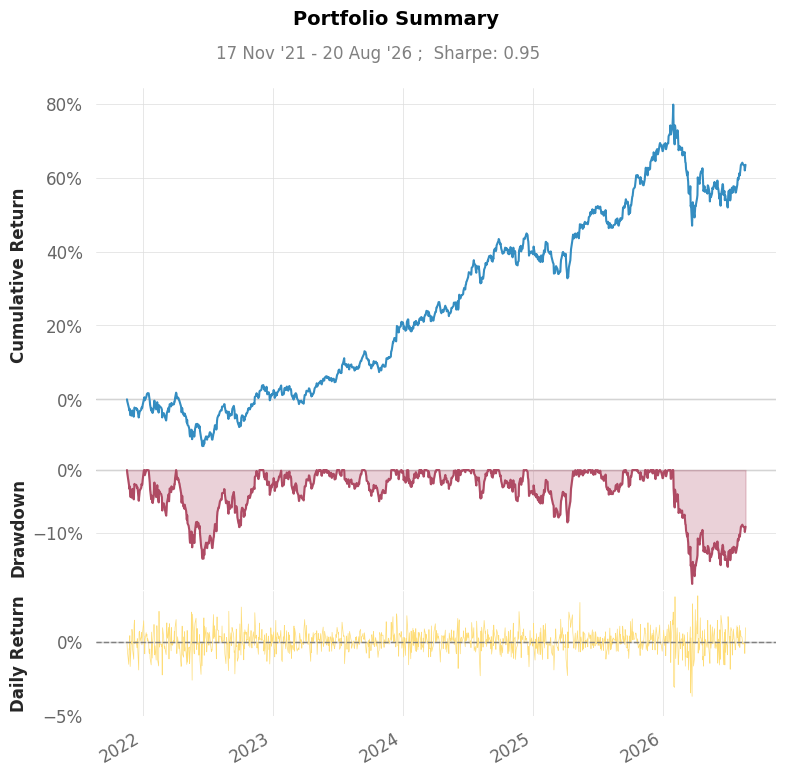

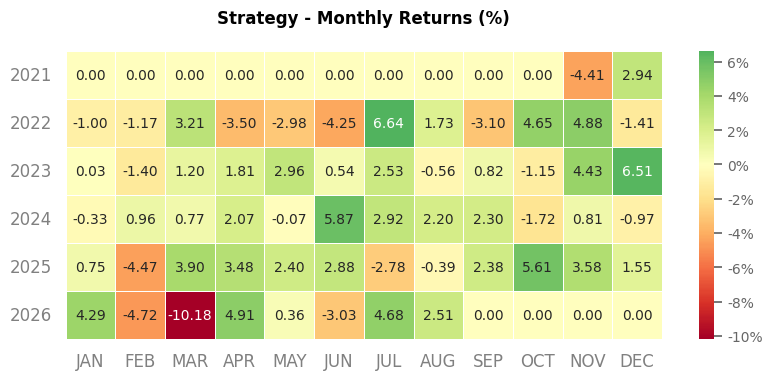


INVERSE VOLATILITY
                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]




Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2021-11-18
End Period           2026-08-20
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    63.7%
CAGR﹪               11.13%

Sharpe               1.03
Prob. Sharpe Ratio   98.65%
Sortino              1.5
Sortino/√2           1.06
Omega                1.19

Max Drawdown         -15.73%
Max DD Date          2026-03-23
Max DD Period Start  2026-01-30
Max DD Period End    2026-08-20
Longest DD Days      225

Gain/Pain Ratio      0.19
Gain/Pain (1M)       1.06

Payoff Ratio         1.04
Profit Factor        1.19
Common Sense Ratio   1.18
CPC Index            0.66
Tail Ratio           0.99
Outlier Win Ratio    3.49
Outlier Loss Ratio   3.48

MTD                  1.99%
3M                   3.37%
6M                   -4.38%
YTD                  -5.18%
1Y   

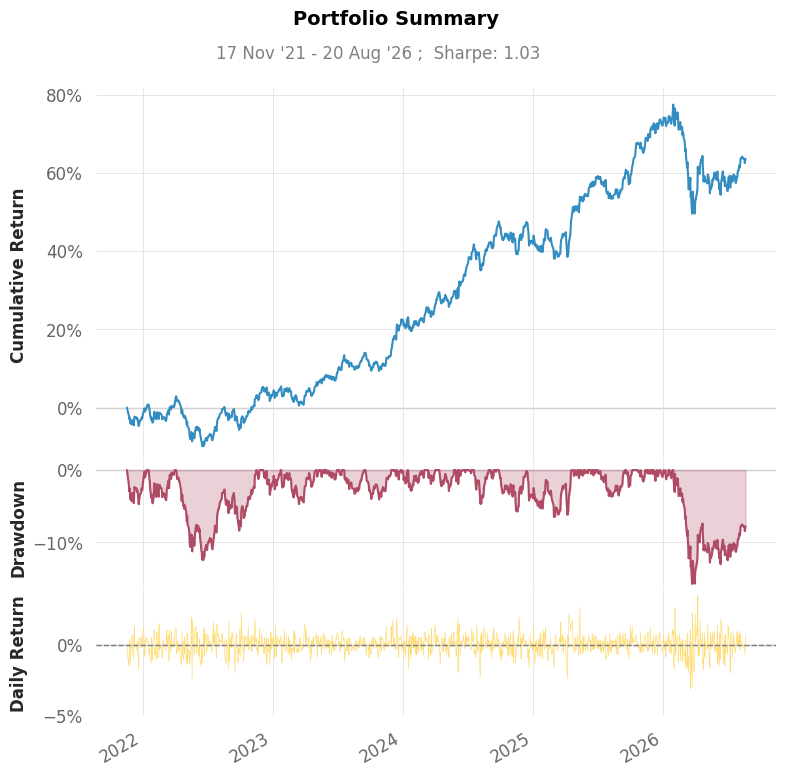

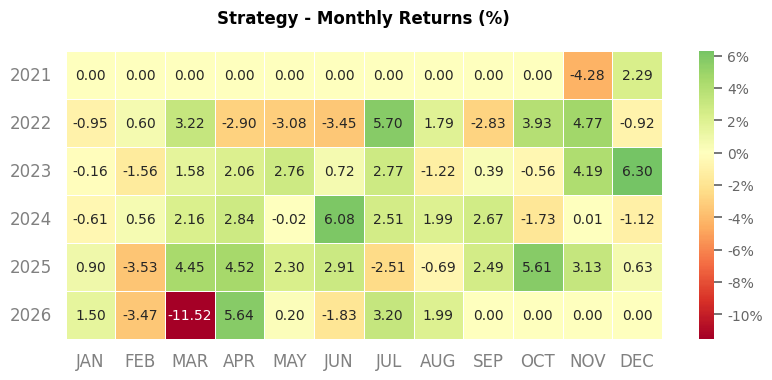


RISK PARITY
                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]




Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2021-11-18
End Period           2026-08-20
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    72.36%
CAGR﹪               12.36%

Sharpe               1.16
Prob. Sharpe Ratio   99.37%
Sortino              1.7
Sortino/√2           1.2
Omega                1.22

Max Drawdown         -16.76%
Max DD Date          2026-03-23
Max DD Period Start  2026-01-30
Max DD Period End    2026-08-20
Longest DD Days      220

Gain/Pain Ratio      0.22
Gain/Pain (1M)       1.29

Payoff Ratio         1.02
Profit Factor        1.22
Common Sense Ratio   1.32
CPC Index            0.67
Tail Ratio           1.08
Outlier Win Ratio    3.47
Outlier Loss Ratio   3.41

MTD                  2.22%
3M                   2.88%
6M                   -4.64%
YTD                  -5.34%
1Y   

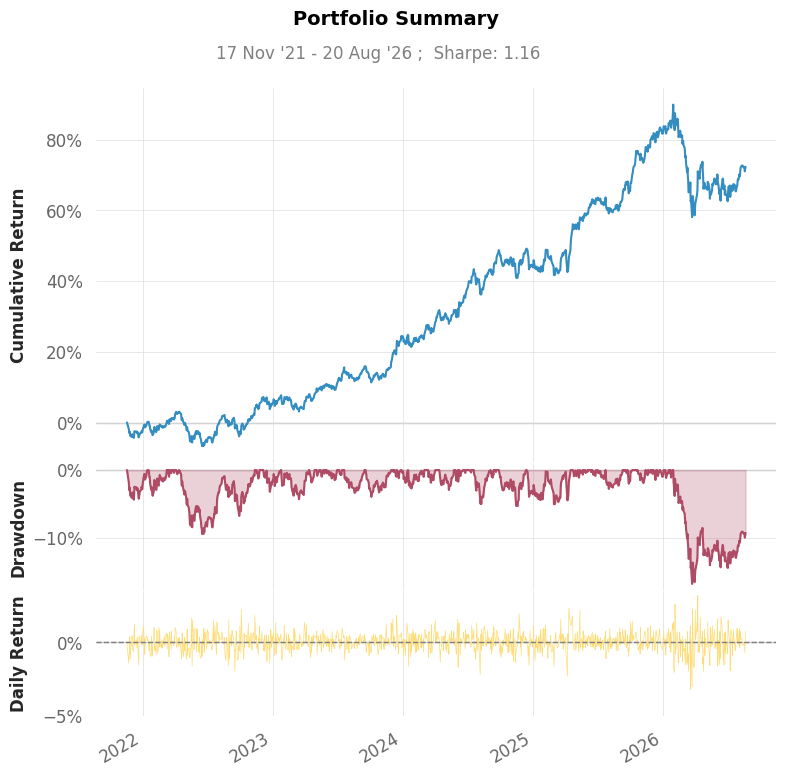

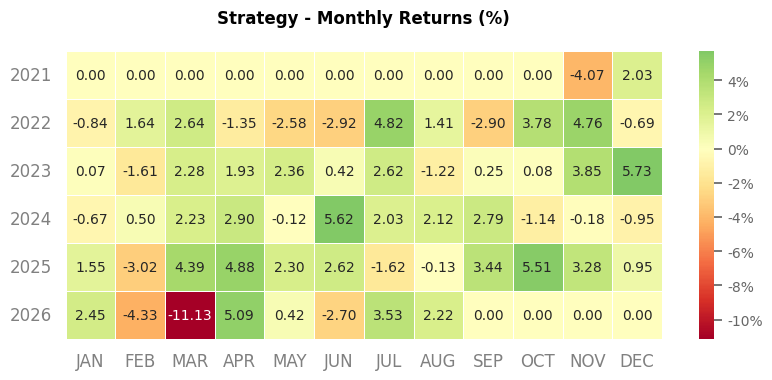


NIFTYBEES BUY & HOLD
                 Parameters
----------------------------------------
Periods/Year                         252
Risk-Free Rate                     0.0%
Compounded                           Yes

[Performance Metrics]




Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2021-11-18
End Period           2026-08-20
Risk-Free Rate       0.0%
Time in Market       100.0%

Cumulative Return    55.29%
CAGR﹪               9.88%

Sharpe               0.68
Prob. Sharpe Ratio   92.73%
Sortino              0.97
Sortino/√2           0.69
Omega                1.13

Max Drawdown         -18.08%
Max DD Date          2026-03-30
Max DD Period Start  2026-02-19
Max DD Period End    2026-08-20
Longest DD Days      203

Gain/Pain Ratio      0.13
Gain/Pain (1M)       0.66

Payoff Ratio         1.01
Profit Factor        1.13
Common Sense Ratio   1.22
CPC Index            0.6
Tail Ratio           1.08
Outlier Win Ratio    3.64
Outlier Loss Ratio   4.15

MTD                  0.64%
3M                   7.95%
6M                   -4.83%
YTD                  -3.11%
1Y   

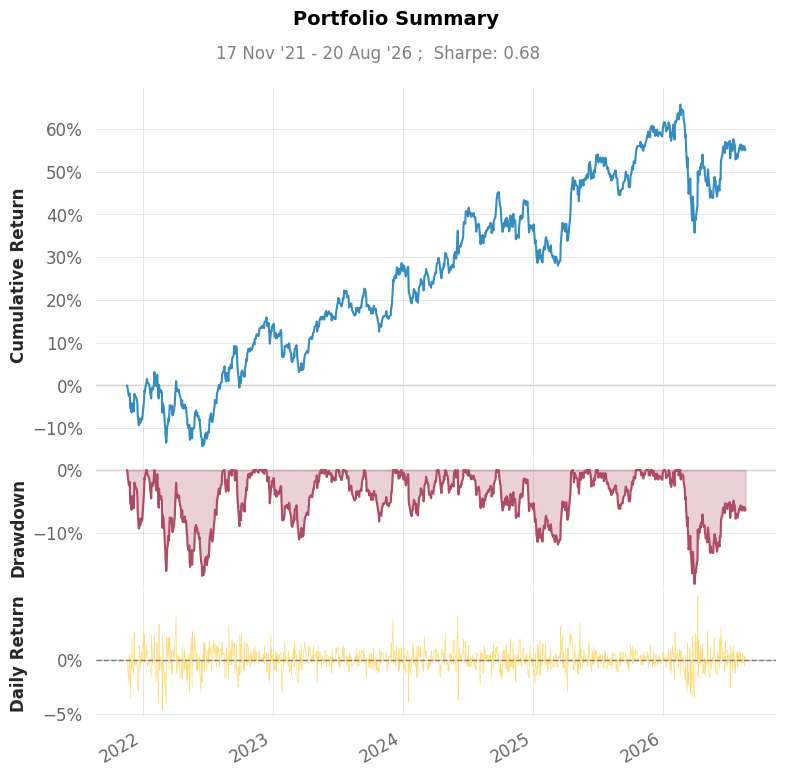

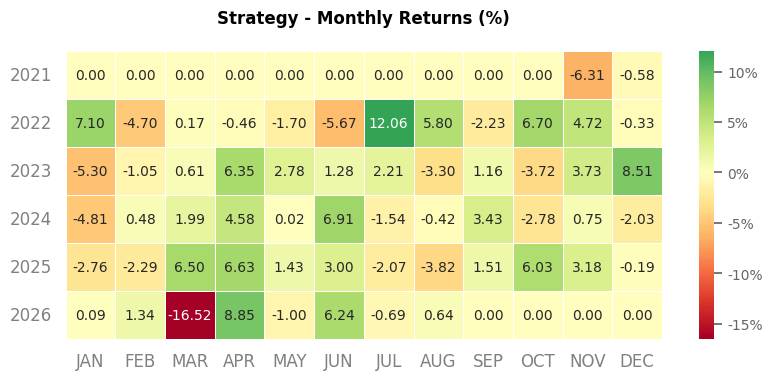


FINAL EQUITY MULTIPLES
Equal Weight            1.635
Inverse Volatility      1.637
Risk Parity             1.724
NIFTYBEES Buy & Hold    1.553
Name: 2026-08-20 00:00:00, dtype: float64


In [10]:
!pip install yfinance quantstats scipy -q

import yfinance as yf
import numpy as np
import pandas as pd
import scipy.optimize as opt
import quantstats as qs

# ============================================================
# 1. DATA
# ============================================================

assets = [
    "NIFTYBEES.NS",
    "GOLDBEES.NS",
    "ITBEES.NS",
    "BANKBEES.NS"
]

prices = yf.download(
    assets,
    period="5y",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

returns = prices.pct_change().dropna()

# Transaction cost per rebalance
COST = 0.0005
WINDOW = 60


# ============================================================
# 2. RISK PARITY
# ============================================================

def risk_parity(cov):

    n = len(cov)

    def objective(w):
        port_vol = np.sqrt(w @ cov @ w)
        rc = w * (cov @ w) / port_vol
        return np.sum((rc - rc.mean()) ** 2)

    result = opt.minimize(
        objective,
        np.ones(n) / n,
        method="SLSQP",
        bounds=[(0.01, 0.60)] * n,
        constraints={
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1
        }
    )

    return result.x


# ============================================================
# 3. BACKTEST
# ============================================================

ew = []
iv = []
rp = []
nifty = []

prev_ew = prev_iv = prev_rp = None

for i in range(WINDOW, len(returns)):

    lookback = returns.iloc[i-WINDOW:i]

    vol = lookback.std() * np.sqrt(252)

    # Equal Weight
    w_ew = np.ones(len(assets)) / len(assets)

    # Inverse Volatility
    inv = 1 / vol
    w_iv = (inv / inv.sum()).values

    # Risk Parity
    cov = lookback.cov().values * 252
    w_rp = risk_parity(cov)

    # Rebalancing cost
    if prev_ew is not None:

        cost_ew = COST * np.abs(w_ew - prev_ew).sum()
        cost_iv = COST * np.abs(w_iv - prev_iv).sum()
        cost_rp = COST * np.abs(w_rp - prev_rp).sum()

    else:

        cost_ew = cost_iv = cost_rp = 0

    r = returns.iloc[i].values

    ew.append(np.dot(w_ew, r) - cost_ew)
    iv.append(np.dot(w_iv, r) - cost_iv)
    rp.append(np.dot(w_rp, r) - cost_rp)

    # NIFTYBEES Buy & Hold
    nifty.append(r[0])

    prev_ew = w_ew
    prev_iv = w_iv
    prev_rp = w_rp


# ============================================================
# 4. RETURN SERIES
# ============================================================

idx = returns.index[WINDOW:]

results = pd.DataFrame({
    "Equal Weight": ew,
    "Inverse Volatility": iv,
    "Risk Parity": rp,
    "NIFTYBEES Buy & Hold": nifty
}, index=idx)


# ============================================================
# 5. PERFORMANCE FUNCTION
# ============================================================

def metrics(r):

    equity = (1 + r).cumprod()

    total_return = equity.iloc[-1] - 1

    years = len(r) / 252

    cagr = equity.iloc[-1] ** (1 / years) - 1

    volatility = r.std() * np.sqrt(252)

    sharpe = (
        r.mean() / r.std() * np.sqrt(252)
    )

    dd = equity / equity.cummax() - 1

    return [
        total_return,
        cagr,
        volatility,
        sharpe,
        dd.min()
    ]


# ============================================================
# 6. COMPARISON
# ============================================================

table = pd.DataFrame(
    {
        name: metrics(results[name])
        for name in results.columns
    },
    index=[
        "Total Return",
        "CAGR",
        "Annual Volatility",
        "Sharpe",
        "Max Drawdown"
    ]
).T

table["Total Return"] *= 100
table["CAGR"] *= 100
table["Annual Volatility"] *= 100
table["Max Drawdown"] *= 100

print("\n" + "="*70)
print("PORTFOLIO STRATEGY COMPARISON")
print("="*70)

print(table.round(2))


# ============================================================
# 7. QUANTSTATS
# ============================================================

for name in results.columns:

    print("\n" + "="*70)
    print(name.upper())
    print("="*70)

    qs.reports.basic(results[name])


# ============================================================
# 8. CUMULATIVE PERFORMANCE
# ============================================================

equity = (1 + results).cumprod()

print("\nFINAL EQUITY MULTIPLES")
print("="*70)

print(
    equity.iloc[-1].round(3)
)